# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")

import networkx as nx
from sklearn.manifold import SpectralEmbedding

# Load data

Selected N=600 images total (200 each) from digits: [0, 1, 2]


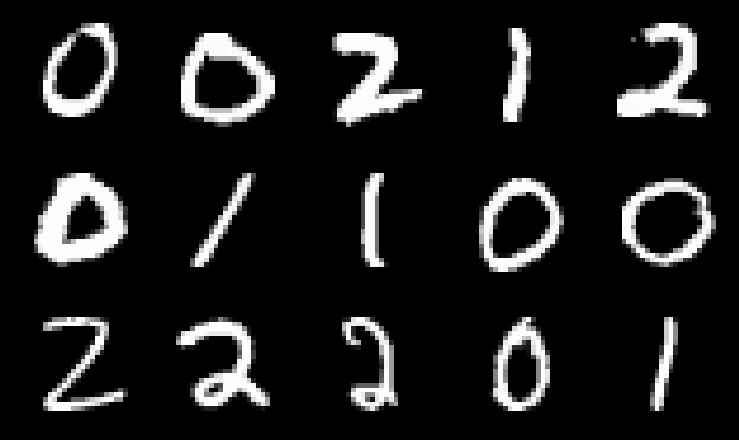

In [2]:
# -----------------------------
# 1) Load MNIST
# -----------------------------
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_all = np.concatenate([X_train, X_test], axis=0).astype(np.float32)  # (70000, 28, 28)
y_all = np.concatenate([y_train, y_test], axis=0).astype(int)         # (70000,)

# -----------------------------
# 2) Choose which digits + how many per digit
# -----------------------------
digits_to_include = [0, 1, 2]   # edit this
n_per_digit = 200               # single knob for all digits

rng = np.random.default_rng()

selected_images = []
selected_labels = []

for d in digits_to_include:
    idx = np.where(y_all == d)[0]
    if len(idx) < n_per_digit:
        raise ValueError(f"Not enough samples for digit {d}: requested {n_per_digit}, found {len(idx)}")
    pick = rng.choice(idx, size=n_per_digit, replace=False)
    selected_images.append(X_all[pick])
    selected_labels.append(y_all[pick])

X = np.concatenate(selected_images, axis=0)  # (N, 28, 28)
y = np.concatenate(selected_labels, axis=0) # (N,)
N = X.shape[0]

print(f"Selected N={N} images total ({n_per_digit} each) from digits:", digits_to_include)

# -----------------------------
# 3) Show a 5x3 grid of example images (15 total)
# -----------------------------
grid_rows, grid_cols = 3, 5
grid_n = grid_rows * grid_cols
grid_idx = rng.choice(np.arange(N), size=grid_n, replace=False)

size = 1.5
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(size*grid_cols, size*grid_rows))
for ax, i in zip(axes.ravel(), grid_idx):
    ax.imshow(X[i], cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Calculate similarity and embeddings

RAW MNIST subset | W range: (0.0, 1.0)


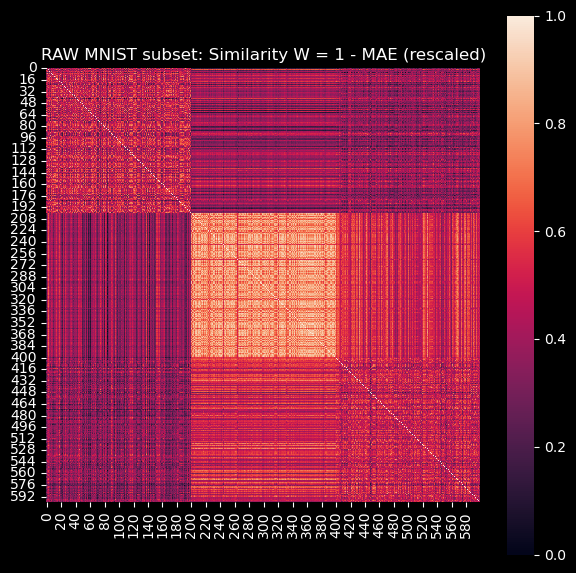

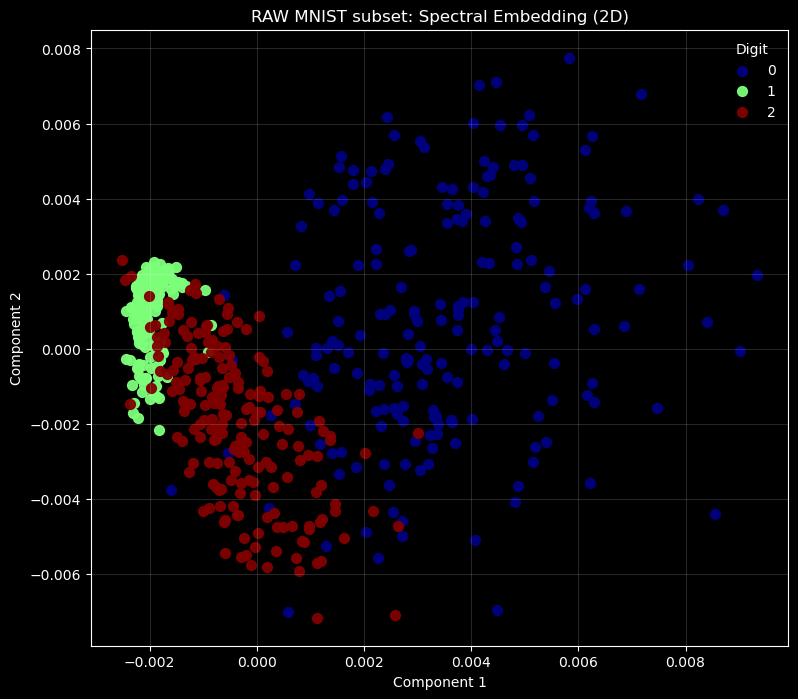

In [3]:
# ============================================================
# Helper: similarity + spectral embedding plot (reused twice)
# ============================================================
def mae_similarity_embedding(images_28x28: np.ndarray, labels: np.ndarray, title_prefix: str, rng: np.random.Generator):
    """
    images_28x28: (N,28,28) float32 [0,255] (or any scale; we max-normalize per image)
    labels: (N,) int
    Produces:
      - similarity heatmap
      - 2D spectral embedding scatter colored by digit
    Returns: (W, Z) where W is similarity matrix, Z is 2D embedding
    """
    N = images_28x28.shape[0]
    X_flat = images_28x28.reshape(N, -1).astype(np.float32)

    # per-image max normalization -> pixel values in [0,1]
    max_per_img = np.max(X_flat, axis=1, keepdims=True)
    max_per_img = np.where(max_per_img == 0, 1.0, max_per_img)
    X_norm = X_flat / max_per_img

    # pairwise MAE -> similarity = 1 - MAE
    diff = np.abs(X_norm[:, None, :] - X_norm[None, :, :])   # (N, N, 784)
    D = diff.mean(axis=2)                                    # (N, N) in [0,1]
    W = 1.0 - D
    np.fill_diagonal(W, 1.0)

    # rescale to [0,1] using global min for nicer contrast
    W = (W - W.min()) / (1.0 - W.min() + 1e-12)
    
    print(f"{title_prefix} | W range:", (float(W.min()), float(W.max())))

    # heatmap
    plt.figure(figsize=(7, 7))
    sns.heatmap(W, square=True, cbar=True)
    plt.title(f"{title_prefix}: Similarity W = 1 - MAE (rescaled)", color="white")
    plt.show()

    # spectral embedding
    embedder = SpectralEmbedding(n_components=2, affinity="precomputed", random_state=42)
    Z = embedder.fit_transform(W)

    classes = np.unique(labels)
    cmap = plt.get_cmap("jet")
    denom = max(1, len(classes) - 1)
    class_to_color = {c: cmap(i / denom) for i, c in enumerate(classes)}

    plt.figure(figsize=(9, 8))
    for c in classes:
        mask = (labels == c)
        plt.scatter(
            Z[mask, 0], Z[mask, 1],
            s=50,
            color=class_to_color[c],
            label=str(c),
            alpha=0.95
        )

    plt.title(f"{title_prefix}: Spectral Embedding (2D)", color="white")
    plt.xlabel("Component 1", color="white")
    plt.ylabel("Component 2", color="white")
    plt.legend(title="Digit", frameon=False)
    plt.grid(alpha=0.15)
    plt.show()

    return W, Z

# ============================================================
# A) ORIGINAL PIPELINE (raw images) up to embedding plot
# ============================================================
W_raw, Z_raw = mae_similarity_embedding(X, y, title_prefix="RAW MNIST subset", rng=rng)

# Normalize images (shift, rotate, scale)

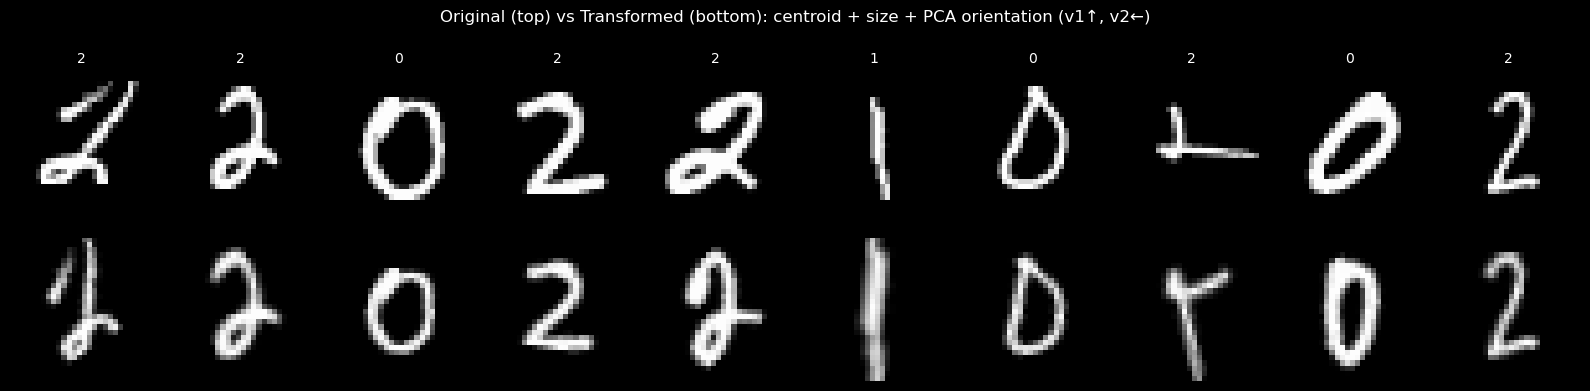

In [4]:
# ============================================================
# B) Align/normalize images (centroid + scale + PCA rotation)
# ============================================================
def intensity_centroid(img: np.ndarray, eps: float = 1e-8):
    img = img.astype(np.float32)
    total = img.sum()
    h, w = img.shape
    if total < eps:
        return (h - 1) / 2.0, (w - 1) / 2.0  # (cy, cx)
    ys, xs = np.indices(img.shape)
    cy = (ys * img).sum() / total
    cx = (xs * img).sum() / total
    return cy, cx

def bilinear_sample(img: np.ndarray, yy: np.ndarray, xx: np.ndarray):
    h, w = img.shape
    y0 = np.floor(yy).astype(int)
    x0 = np.floor(xx).astype(int)
    y1 = y0 + 1
    x1 = x0 + 1
    wy = yy - y0
    wx = xx - x0

    def get(y, x):
        mask = (0 <= y) & (y < h) & (0 <= x) & (x < w)
        out = np.zeros_like(yy, dtype=np.float32)
        out[mask] = img[y[mask], x[mask]]
        return out

    I00 = get(y0, x0)
    I10 = get(y1, x0)
    I01 = get(y0, x1)
    I11 = get(y1, x1)

    return ((1 - wy) * (1 - wx) * I00 +
            (wy)     * (1 - wx) * I10 +
            (1 - wy) * (wx)     * I01 +
            (wy)     * (wx)     * I11)

def affine_warp(img: np.ndarray, M: np.ndarray, out_shape=None):
    if out_shape is None:
        out_shape = img.shape
    h, w = out_shape
    ys, xs = np.indices((h, w))
    xs_f = xs.astype(np.float32)
    ys_f = ys.astype(np.float32)
    x_in = M[0,0]*xs_f + M[0,1]*ys_f + M[0,2]
    y_in = M[1,0]*xs_f + M[1,1]*ys_f + M[1,2]
    return bilinear_sample(img.astype(np.float32), y_in, x_in)

def weighted_pca_axes(img: np.ndarray, eps: float = 1e-8):
    img = img.astype(np.float32)
    total = img.sum()
    h, w = img.shape

    if total < eps:
        mx, my = (w - 1) / 2.0, (h - 1) / 2.0
        lam1, lam2 = 1.0, 0.5
        v1 = np.array([1.0, 0.0], dtype=np.float32)
        v2 = np.array([0.0, 1.0], dtype=np.float32)
        return (float(mx), float(my)), (float(lam1), float(lam2)), v1, v2

    ys, xs = np.indices((h, w))
    x = xs.ravel().astype(np.float32)
    y = ys.ravel().astype(np.float32)
    wts = img.ravel()

    mx = float((x * wts).sum() / total)
    my = float((y * wts).sum() / total)

    Xc = np.stack([x - mx, y - my], axis=1)
    cov = (Xc * wts[:, None]).T @ Xc / (total + eps)

    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    v1 = evecs[:, 0].astype(np.float32)
    v2 = evecs[:, 1].astype(np.float32)

    if np.linalg.det(np.stack([v1, v2], axis=1)) < 0:
        v2 = -v2

    return (mx, my), (float(evals[0]), float(evals[1])), v1, v2

def normalize_digit_up_left(img: np.ndarray,
                            target_std=4.5,
                            std_clip=(2.0, 8.0),
                            scale_clip=(0.6, 1.8),
                            eps: float = 1e-8):
    img = img.astype(np.float32)
    h, w = img.shape

    cy_t, cx_t = (h - 1) / 2.0, (w - 1) / 2.0
    cy, cx = intensity_centroid(img, eps=eps)
    shift_x = cx_t - cx
    shift_y = cy_t - cy

    (_, _), (lam1, lam2), v1, v2 = weighted_pca_axes(img, eps=eps)

    # v1 up
    if v1[1] > 0:
        v1 = -v1
        v2 = -v2
    # v2 left
    if v2[0] > 0:
        v2 = -v2

    A = np.stack([v1, v2], axis=1)
    u1 = np.array([0.0, -1.0], dtype=np.float32)
    u2 = np.array([-1.0, 0.0], dtype=np.float32)
    B = np.stack([u1, u2], axis=1)
    R = B @ A.T

    std1 = float(np.sqrt(max(lam1, eps)))
    std2 = float(np.sqrt(max(lam2, eps)))
    std_avg = float(np.clip((std1 + std2) / 2.0, std_clip[0], std_clip[1]))
    scale = float(np.clip(target_std / (std_avg + eps), scale_clip[0], scale_clip[1]))

    inv_scale = 1.0 / scale
    Ainv = (inv_scale * R.T).astype(np.float32)

    center = np.array([cx_t, cy_t], dtype=np.float32)   # (x,y)
    shift = np.array([shift_x, shift_y], dtype=np.float32)

    b = center - shift - (Ainv @ center)

    M = np.zeros((2, 3), dtype=np.float32)
    M[:, :2] = Ainv
    M[:, 2] = b

    out = affine_warp(img, M, out_shape=(h, w))
    return out

# Transform all selected images
X_t = np.stack([normalize_digit_up_left(img, target_std=4.5) for img in X], axis=0)

# Pedagogical display: top row originals, bottom row transformed
n_show = 10
idx_show = rng.choice(np.arange(N), size=n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(1.6 * n_show, 4.2))
fig.suptitle("Original (top) vs Transformed (bottom): centroid + size + PCA orientation (v1↑, v2←)", color="white", y=0.98)

for j in range(n_show):
    axes[0, j].imshow(X[idx_show[j]], cmap="gray", vmin=0, vmax=255)
    axes[0, j].set_title(str(y[idx_show[j]]), color="white", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(X_t[idx_show[j]], cmap="gray", vmin=0, vmax=255)
    axes[1, j].axis("off")

plt.tight_layout()
plt.show()

# Calculate similarity and embeddings

TRANSFORMED MNIST subset | W range: (0.0, 1.0)


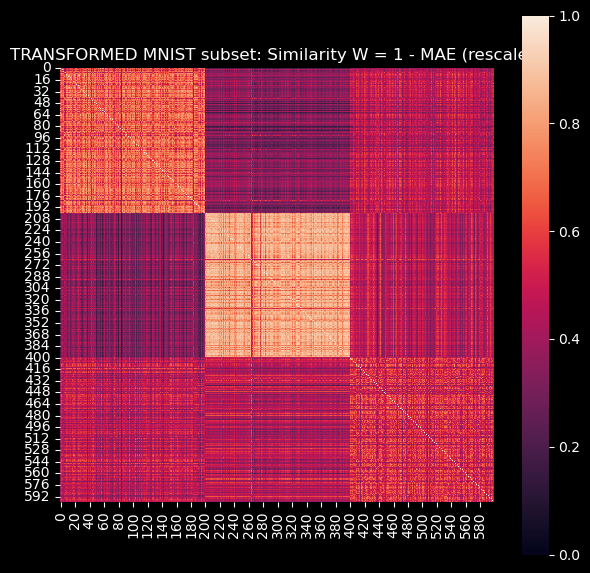

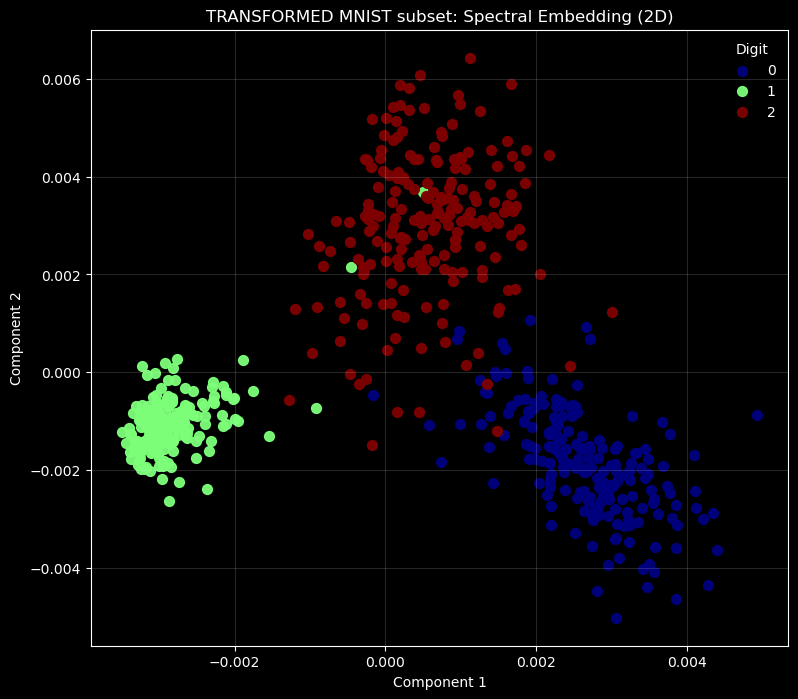

In [5]:
# ============================================================
# C) TRANSFORMED PIPELINE (aligned images) again: similarity + embedding
# ============================================================
W_t, Z_t = mae_similarity_embedding(X_t, y, title_prefix="TRANSFORMED MNIST subset", rng=rng)